# Roman QSO Emission-Line Detection Probability

Goal:

At a given UV continuum luminosity, estimate the probability that
a QSO emission line is luminous enough to exceed Roman's line-flux
detection limit.

The SDSS DR16Q spectral-property catalog from Wu & Shen (2022) is
used to empirically estimate the conditional line-luminosity
distribution P(L_line | L_1350).

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.table import Table
from astropy import units as u
from astropy.cosmology import FlatLambdaCDM
from scipy.ndimage import gaussian_filter

filename = "dr16q_prop_Oct20_2022.fits"
catalog = Table.read(filename, hdu=1)

z = catalog["Z_SYS"]
logL1350 = catalog["LOGL1350"]

logL_Halpha = catalog["HALPHA"][:, 3]
logL_Hbeta  = catalog["HBETA"][:, 3]
logL_MgII   = catalog["MGII"][:, 3]
logL_CIV    = catalog["CIV"][:, 3]

print("Number of QSOs:", len(catalog))

Number of QSOs: 750414


In [9]:
#open shen 2011 catalog

import gzip
import shutil

with gzip.open("catalog.dat.gz", "rb") as f_in:
    with open("catalog.dat", "wb") as f_out:
        shutil.copyfileobj(f_in, f_out)

from astropy.table import Table

shen2011 = Table.read(
    "catalog.dat",
    format="ascii.cds",
    readme="ReadMe.txt"
)

print("Number of Shen 2011 QSOs:", len(shen2011))

Number of Shen 2011 QSOs: 105783


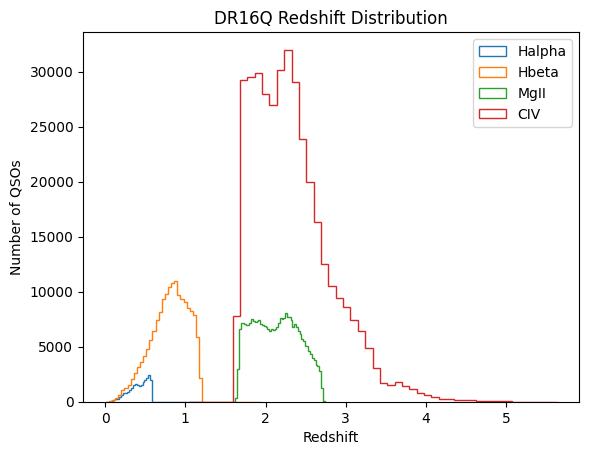

In [10]:
good_Halpha = (z > 0) & (logL_Halpha > 38) & (logL_Halpha < 48)
good_Hbeta  = (z > 0) & (logL_Hbeta > 38) & (logL_Hbeta < 48)

good_MgII = (
    (z > 0)
    & (logL1350 > 0)
    & (logL_MgII > 38)
    & (logL_MgII < 48)
)

good_CIV = (
    (z > 0)
    & (logL1350 > 0)
    & (logL_CIV > 38)
    & (logL_CIV < 48)
)

plt.hist(z[good_Halpha], bins=50, histtype="step", label="Halpha")
plt.hist(z[good_Hbeta],  bins=50, histtype="step", label="Hbeta")
plt.hist(z[good_MgII],   bins=50, histtype="step", label="MgII")
plt.hist(z[good_CIV],    bins=50, histtype="step", label="CIV")

plt.xlabel("Redshift")
plt.ylabel("Number of QSOs")
plt.title("DR16Q Redshift Distribution")
plt.legend()
plt.show()

## Redshift structure

The bumps in the redshift distributions do not necessarily mean
that more quasars physically exist at those redshifts.

The SDSS catalog is affected by how quasars were selected for
observation and by the wavelength range of the SDSS spectrographs.

For example, as redshift increases, an emission line shifts to longer
observed wavelengths. Eventually the line can move outside the
spectrograph wavelength range and can no longer be measured.

Therefore, some bumps or drops in the redshift distributions may be
caused by observational selection rather than the true QSO population.

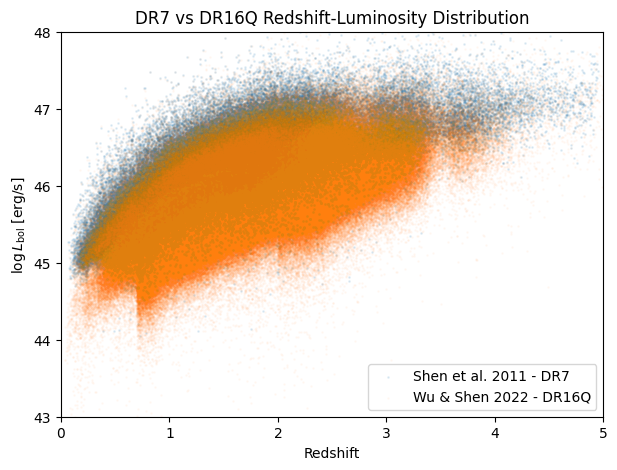

In [11]:
# Compare Shen et al. 2011 DR7 with Wu & Shen 2022 DR16Q

# Old catalog: Shen et al. 2011
z_old = shen2011["z"]
Lbol_old = shen2011["logLbol"]

good_old = (
    (z_old > 0)
    & (Lbol_old > 0)
)

# New catalog: Wu & Shen 2022
z_new = catalog["Z_SYS"]
Lbol_new = catalog["LOGLBOL"]

good_new = (
    (z_new > 0)
    & (Lbol_new > 0)
)

plt.figure(figsize=(7, 5))

plt.scatter(
    z_old[good_old],
    Lbol_old[good_old],
    s=1,
    alpha=0.1,
    label="Shen et al. 2011 - DR7"
)

plt.scatter(
    z_new[good_new],
    Lbol_new[good_new],
    s=1,
    alpha=0.03,
    label="Wu & Shen 2022 - DR16Q"
)

plt.xlabel("Redshift")
plt.ylabel(r"$\log L_{\rm bol}$ [erg/s]")

plt.xlim(0, 5)
plt.ylim(43, 48)

plt.title("DR7 vs DR16Q Redshift-Luminosity Distribution")

plt.legend()

plt.show()

## DR7 vs DR16Q

The older Shen et al. (2011) DR7 catalog contains about 106,000 QSOs,
while Wu & Shen (2022) DR16Q contains about 750,000 QSOs.

The DR16Q sample covers a broader range of redshift and bolometric
luminosity and includes many more lower-luminosity quasars.

This larger sample is useful for estimating how emission-line
luminosity depends on UV luminosity.

In [16]:
# Roman assumed line-flux limit
f_lim = 1e-16 * u.erg / (u.s * u.cm**2)

cosmo = FlatLambdaCDM(H0=70, Om0=0.3)

# test redshift
z_roman = 3.0

d_L = cosmo.luminosity_distance(z_roman).to(u.cm)

L_lim = (
    4 * np.pi * d_L**2 * f_lim
).to(u.erg / u.s)

logL_lim = np.log10(L_lim.value)

print("Roman test redshift:", z_roman)
print("Roman minimum line luminosity:", L_lim)
print("log10 Roman line-luminosity threshold:", logL_lim)

Roman test redshift: 3.0
Roman minimum line luminosity: 7.733137387272777e+42 erg / s
log10 Roman line-luminosity threshold: 42.88835572594223


## Roman line-luminosity threshold

Roman fundamentally has an observed line-flux threshold.

For an object at redshift z,

L_line,lim(z) = 4 pi d_L(z)^2 F_lim.

For the test case z = 3 and the adopted flux limit,
log10(L_line,lim) = 42.89.

Therefore, 42.8 is NOT a universal Roman luminosity threshold.
The luminosity threshold changes with redshift through d_L(z).

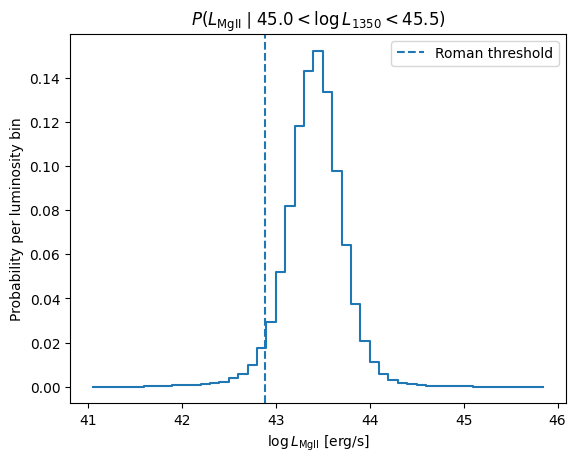

Number of MgII QSOs: 122956
Sum of histogram probabilities: 0.9999105371027034


In [17]:
L_low = 45.0
L_high = 45.5

in_bin_MgII = (
    good_MgII
    & (logL1350 >= L_low)
    & (logL1350 < L_high)
)

MgII_values = logL_MgII[in_bin_MgII]

line_bins = np.arange(41, 46, 0.1)

counts, edges = np.histogram(
    MgII_values,
    bins=line_bins
)

N_qso = len(MgII_values)

P_SDSS = counts / N_qso

bin_centers = 0.5 * (edges[:-1] + edges[1:])

plt.step(
    bin_centers,
    P_SDSS,
    where="mid"
)

plt.axvline(
    logL_lim,
    linestyle="--",
    label="Roman threshold"
)

plt.xlabel(r"$\log L_{\rm MgII}$ [erg/s]")
plt.ylabel("Probability per luminosity bin")

plt.title(
    r"$P(L_{\rm MgII}\mid45.0<\log L_{1350}<45.5)$"
)

plt.legend()
plt.show()

print("Number of MgII QSOs:", N_qso)
print("Sum of histogram probabilities:", np.sum(P_SDSS))

In [18]:
# Approximate BOSS wavelength coverage quoted by Wu & Shen (2022)
lambda_min = 3650.0
lambda_max = 10400.0

lambda_MgII = 2798.0
lambda_1350 = 1350.0

# MgII observable redshift range
zmin_MgII = lambda_min / lambda_MgII - 1
zmax_MgII = lambda_max / lambda_MgII - 1

# L1350 observable redshift range
zmin_1350 = lambda_min / lambda_1350 - 1
zmax_1350 = lambda_max / lambda_1350 - 1

# overlap where both can be observed
zmin_overlap = max(zmin_MgII, zmin_1350)
zmax_overlap = min(zmax_MgII, zmax_1350)

print("MgII range:", zmin_MgII, zmax_MgII)
print("L1350 range:", zmin_1350, zmax_1350)
print("MgII + L1350 overlap:", zmin_overlap, zmax_overlap)

MgII range: 0.30450321658327373 2.716940671908506
L1350 range: 1.7037037037037037 6.703703703703703
MgII + L1350 overlap: 1.7037037037037037 2.716940671908506


## Why wavelength coverage matters

Using every QSO in an L1350 bin as the denominator would be incorrect,
because some QSOs lie at redshifts where MgII is outside the SDSS/BOSS
spectral range.

Therefore I define an eligible sample in which both the 1350-A
continuum and MgII fall within the observed wavelength range.

This prevents objects with unobservable MgII from being incorrectly
classified as line non-detections.

In [19]:
L1350_bins = np.arange(44.0, 47.5, 0.5)

L1350_centers = []
P_MgII_all = []
P_MgII_error = []
N_eligible_all = []
N_detected_all = []

for L_low, L_high in zip(
    L1350_bins[:-1],
    L1350_bins[1:]
):

    # QSOs for which both L1350 and MgII are observable
    eligible_MgII = (
        (z >= zmin_overlap)
        & (z <= zmax_overlap)
        & (logL1350 > 0)
        & (logL1350 >= L_low)
        & (logL1350 < L_high)
    )

    N_eligible = np.sum(eligible_MgII)

    # valid MgII measurement above Roman threshold
    detected_MgII = (
        eligible_MgII
        & (logL_MgII > 38)
        & (logL_MgII < 48)
        & (logL_MgII >= logL_lim)
    )

    N_detected = np.sum(detected_MgII)

    if N_eligible > 0:

        P_Roman = N_detected / N_eligible

        P_error = np.sqrt(
            P_Roman * (1 - P_Roman)
            / N_eligible
        )

    else:

        P_Roman = np.nan
        P_error = np.nan

    L1350_centers.append(
        (L_low + L_high) / 2
    )

    P_MgII_all.append(P_Roman)
    P_MgII_error.append(P_error)

    N_eligible_all.append(N_eligible)
    N_detected_all.append(N_detected)

    print(
        f"{L_low:.1f}-{L_high:.1f}: "
        f"N = {N_eligible}, "
        f"N_detected = {N_detected}, "
        f"P = {P_Roman:.4f} +/- {P_error:.4f}"
    )

44.0-44.5: N = 4061, N_detected = 3088, P = 0.7604 +/- 0.0067
44.5-45.0: N = 36740, N_detected = 31206, P = 0.8494 +/- 0.0019
45.0-45.5: N = 119689, N_detected = 111508, P = 0.9316 +/- 0.0007
45.5-46.0: N = 98228, N_detected = 94307, P = 0.9601 +/- 0.0006
46.0-46.5: N = 30607, N_detected = 29574, P = 0.9662 +/- 0.0010
46.5-47.0: N = 3285, N_detected = 3126, P = 0.9516 +/- 0.0037


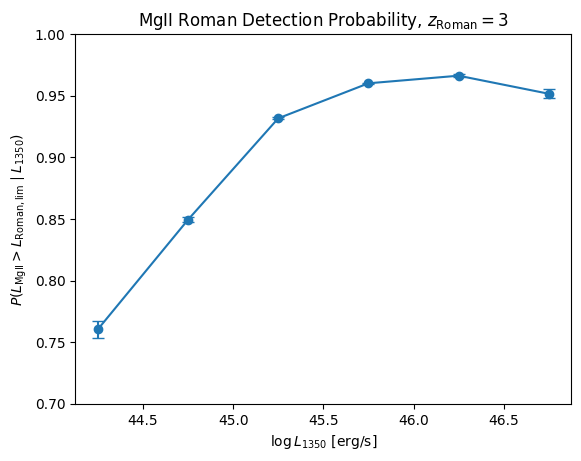

In [20]:
plt.errorbar(
    L1350_centers,
    P_MgII_all,
    yerr=P_MgII_error,
    marker="o",
    capsize=4
)

plt.xlabel(r"$\log L_{1350}$ [erg/s]")

plt.ylabel(
    r"$P(L_{\rm MgII}>L_{\rm Roman,lim}\mid L_{1350})$"
)

plt.title(
    r"MgII Roman Detection Probability, $z_{\rm Roman}=3$"
)

plt.ylim(0.70, 1.0)

plt.show()

In [21]:
from astropy.table import Table

results = Table(
    [
        L1350_centers,
        N_eligible_all,
        N_detected_all,
        P_MgII_all,
        P_MgII_error
    ],
    names=[
        "logL1350_center",
        "N_eligible",
        "N_detected",
        "P_Roman_MgII",
        "sigma_P"
    ]
)

print(results)

logL1350_center N_eligible N_detected    P_Roman_MgII           sigma_P       
--------------- ---------- ---------- ------------------ ---------------------
          44.25       4061       3088 0.7604038414183698  0.006698006763282214
          44.75      36740      31206 0.8493739793140991 0.0018660784670940214
          45.25     119689     111508 0.9316478540216728   0.00072941527165638
          45.75      98228      94307 0.9600826648206214 0.0006246222259487737
          46.25      30607      29574 0.9662495507563629 0.0010322242310269675
          46.75       3285       3126 0.9515981735159817  0.003744466833229198


## Halpha and Hbeta

Direct estimation of P(L_Halpha | L1350) and
P(L_Hbeta | L1350) is not currently possible from the same objects
in this catalog because the rest-frame 1350-A continuum and these
optical lines do not have useful simultaneous spectral coverage over
the relevant redshift ranges.

A continuum conversion or empirical relation will therefore be needed
to connect Halpha/Hbeta measurements to the UV luminosity used in the
QLF.

This part is left for subsequent treatment.

# Connection to the Roman QSO Number Forecast

The previous QLF calculation gives the number of QSOs expected as a
function of UV luminosity and redshift:

N_QSO(L_UV, z).

The SDSS analysis developed here provides the probability that an
emission line exceeds Roman's detection threshold:

P_det(L_UV, z).

The final Roman line-detected QSO forecast will therefore use

N_Roman = sum N_QSO(L_UV, z) P_det(L_UV, z),

or, continuously,

N_Roman =
integral Phi(M,z) P_det(M,z) (dV/dz) dM dz.

Therefore the previous QLF integration must eventually be performed
in UV-luminosity bins rather than assigning one detection probability
to the entire QSO population.